In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

In [6]:
cursor.execute("DELETE FROM sales")
conn.commit()

In [7]:
cursor.execute("""
    CREATE TABLE IF NOT EXISTS sales (
        id INTEGER PRIMARY KEY,
        product TEXT,
        quantity INTEGER,
        price REAL
    )
""")

# Insert sample data
sample_data = [
    ("Product A", 10, 5.0),
    ("Product B", 8, 7.5),
    ("Product A", 12, 5.0),
    ("Product C", 15, 10.0),
    ("Product B", 5, 7.5)
]
cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
conn.commit()

# SQL query to fetch total quantity, price, and revenue
query = """
    SELECT product, SUM(quantity) AS total_qty, AVG(price) AS price, SUM(quantity * price) AS revenue
    FROM sales
    GROUP BY product
"""

# Load into a pandas DataFrame
df = pd.read_sql_query(query, conn)
print("Sales Summary")
conn.close()

df

Sales Summary


,product,total_qty,price,revenue
0,Product A,22,5.0,110.0
1,Product B,13,7.5,97.5
2,Product C,15,10.0,150.0


<Figure size 800x500 with 0 Axes>

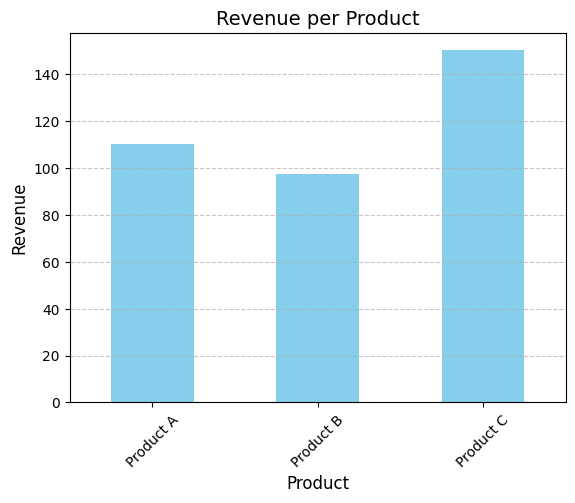

In [12]:
plt.figure(figsize=(8,5))
df.plot(kind='bar', x ='product',y='revenue',legend = False, color ='skyblue')
plt.title("Revenue per Product", fontsize=14)
plt.xlabel("Product", fontsize=12)
plt.ylabel("Revenue", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.savefig("sales_chart.png")
plt.show()

<Figure size 800x500 with 0 Axes>

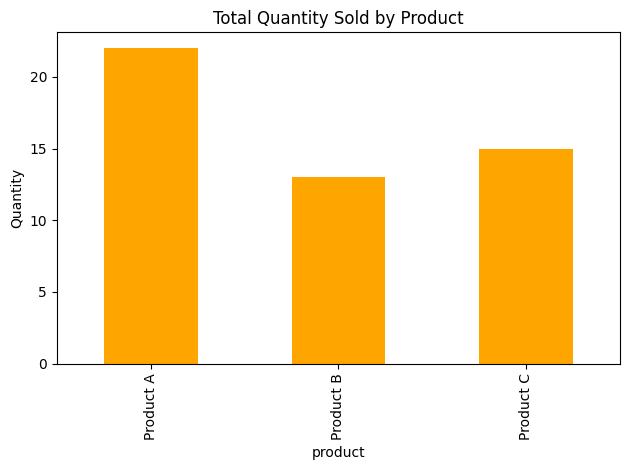

In [13]:
plt.figure(figsize=(8, 5))
df.plot(kind='bar', x='product', y='total_qty', title='Total Quantity Sold by Product', legend=False, color='orange')
plt.ylabel("Quantity")
plt.tight_layout()
plt.show()


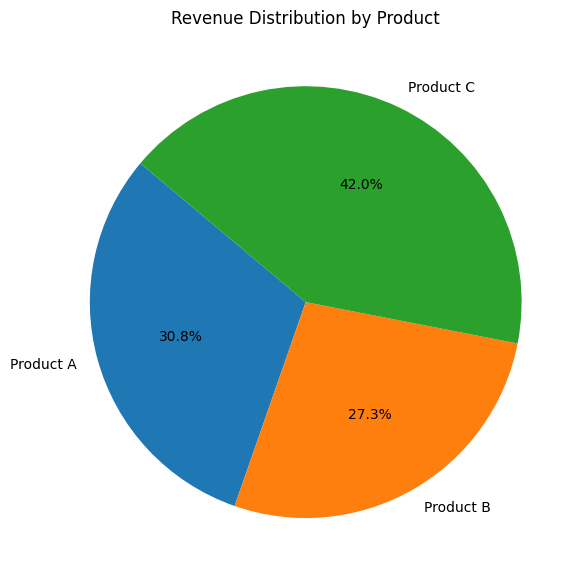

In [14]:
plt.figure(figsize=(6, 6))
plt.pie(df['revenue'], labels=df['product'], autopct='%1.1f%%', startangle=140)
plt.title("Revenue Distribution by Product")
plt.tight_layout()
plt.show()
